<a href="https://colab.research.google.com/github/rizkiismail9a/data-science-2026-unsia/blob/main/pertemuan_7_Muhamad_Rizki_Ismail_240401010126.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (569, 30)
Distribusi target: 
1    0.627
0    0.373
Name: proportion, dtype: float64
                  Fitur  Koefisien
21        worst texture  -1.350606
10         radius error  -1.268178
28       worst symmetry  -1.208200
7   mean concave points  -1.119804
26      worst concavity  -0.943053


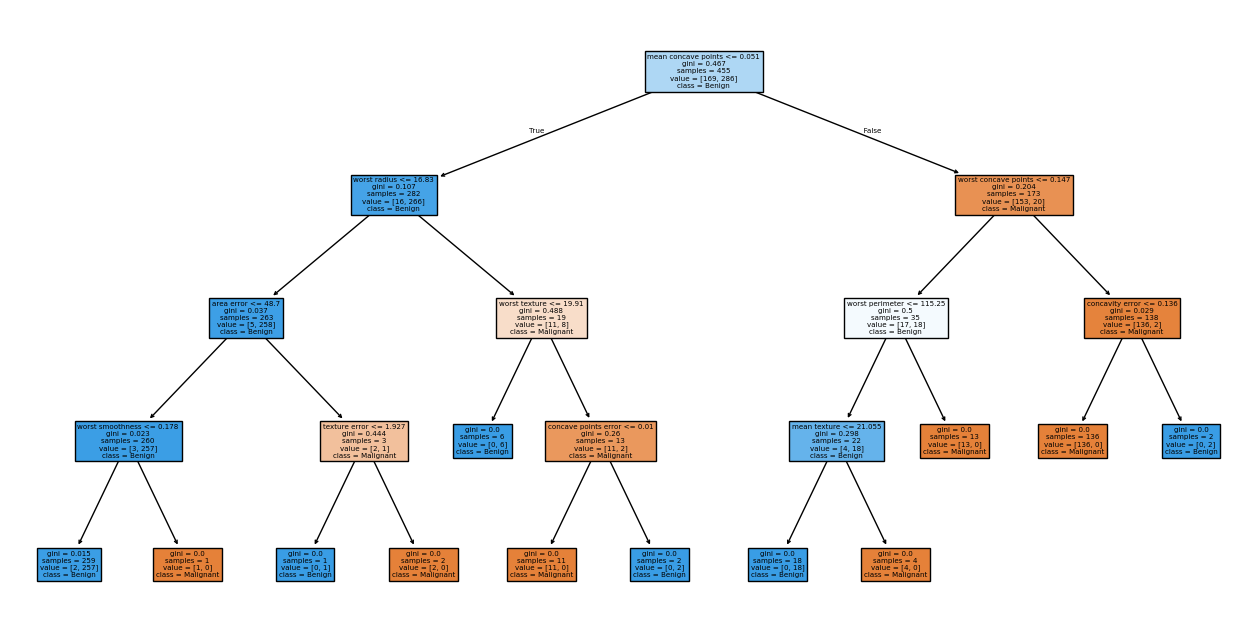


=== Logistic Regression ===
[[41  2]
 [ 1 70]]
Accuracy : 0.974
Precision: 0.972
Recall : 0.986
F1-Score : 0.979

=== Decision Tree ===
[[40  3]
 [ 3 68]]
Accuracy : 0.947
Precision: 0.958
Recall : 0.958
F1-Score : 0.958


In [18]:
#------------------------#
# Nama: Muhamad Rizki Ismail
# NIM: 240401010126
# Kelas: IF401
# Mata Kuliah: Data Science
#------------------------#

# Handson

from sklearn.datasets import load_breast_cancer
import pandas as pd

# EDA
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# print(X)

print('Shape:', X.shape)
print('Distribusi target: ')
print(pd.Series(y).value_counts(normalize=True).round(3))

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Latih Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({'Fitur': X.columns,
'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head())

# Latih Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
# Pakai X_train karena Decision Tree gak perlu scaling
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)


plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns, class_names=['Malignant','Benign'], filled=True)
plt.show()


# Evaluasi Model
from sklearn.metrics import (confusion_matrix,accuracy_score, precision_score, recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
  print(f"\n=== {name} ===")
  print(confusion_matrix(y_test, y_pred))
  print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
  print(f"Precision: {precision_score(y_test, y_pred):.3f}")
  print(f"Recall : {recall_score(y_test, y_pred):.3f}")
  print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")

## Simpulan

Notebook ini melakukan klasifikasi kanker payudara menggunakan dua model: **Regresi Logistik** dan **Decision Tree**.

Langkah-langkah yang dilakukan:

1.  **Eksplorasi Data Awal (EDA)**:
    *   Memuat dataset `breast_cancer` dari `sklearn.datasets`.
    *   Menampilkan bentuk data (`X.shape`) yaitu (569, 30) yang berarti ada 569 sampel dengan 30 fitur.
    *   Menampilkan distribusi target (`y`), menunjukkan bahwa sekitar 62.7% adalah 'Benign' (kelas 1) dan 37.3% adalah 'Malignant' (kelas 0).

2.  **Pra-pemrosesan Data**:
    *   Data dibagi menjadi set pelatihan (80%) dan pengujian (20%) menggunakan `train_test_split` dengan `random_state=42`.
    *   Fitur-fitur diskalakan menggunakan `StandardScaler` untuk set pelatihan dan pengujian. Scaling diperlukan untuk Regresi Logistik.

3.  **Pelatihan Model Regresi Logistik**:
    *   Model `LogisticRegression` dilatih pada data yang telah diskalakan (`X_train_s`, `y_train`).
    *   Koefisien fitur dari model regresi logistik ditampilkan, menunjukkan fitur-fitur yang paling berpengaruh (berdasarkan nilai absolut koefisien).

4.  **Pelatihan Model Decision Tree**:
    *   Model `DecisionTreeClassifier` dilatih pada data asli (tanpa scaling) dengan `max_depth=4` dan `random_state=42`.
    *   Visualisasi pohon keputusan ditampilkan, menunjukkan struktur keputusan model.

5.  **Evaluasi Model**:
    *   Kedua model dievaluasi menggunakan metrik `confusion_matrix`, `accuracy_score`, `precision_score`, `recall_score`, dan `f1_score` pada set pengujian.
    *   **Regresi Logistik** menunjukkan performa yang sangat baik dengan Akurasi: 0.974, Presisi: 0.972, Recall: 0.986, dan F1-Score: 0.979.
    *   **Decision Tree** juga menunjukkan performa yang baik dengan Akurasi: 0.947, Presisi: 0.958, Recall: 0.958, dan F1-Score: 0.958.

Secara keseluruhan, kedua model berhasil mengklasifikasikan kanker payudara dengan akurasi tinggi, dengan Regresi Logistik sedikit mengungguli Decision Tree pada dataset ini.